## In this the real save state did not trim but we take the state and store trim in another variable and passed that to llm  but state saved in memory state remain unaffected

In [1]:
import os
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.messages.utils import trim_messages,count_tokens_approximately

In [18]:
from langchain_core.messages import BaseMessage, HumanMessage


In [2]:
load_dotenv()
api_key = os.environ['GROQ_API_KEY1']
model = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
    api_key=api_key,
    verbose=True,
    # other params...
)

In [3]:
MAX_TOKENS = 150

In [4]:
def call_model(state: MessagesState):
    
    # Trim conversation history -> last N messages that fit within the token budget
    messages = trim_messages(
        state["messages"],
        strategy="last",                      
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS
    )

    print('Current Token Count ->', count_tokens_approximately(messages=messages))

    for message in messages:
        print(message.content)

    response = model.invoke(messages)

    return {"messages": [response]}

In [5]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [6]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

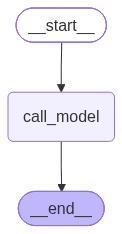

In [7]:
graph

In [9]:
config = {"configurable": {"thread_id": "chat-1"}}

init_state = {"messages": [{"role": "user", "content": "Hi, my name is RAM."}]}
result = graph.invoke(
    init_state,
    config,
)

result["messages"][-1].content

Current Token Count -> 39
Hi, my name is Nitish.
Hello Nitish! Nice to meet you. How can I assist you today?
Hi, my name is RAM.


'Nice to meet you, Ram! How can I help you today?'

In [10]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "I am learning LangGraph."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 67
Hi, my name is Nitish.
Hello Nitish! Nice to meet you. How can I assist you today?
Hi, my name is RAM.
Nice to meet you, Ram! How can I help you today?
I am learning LangGraph.


'That’s great! LangGraph is a powerful library for building **state‑driven, multi‑step LLM applications** (think agents, workflows, and complex conversational assistants). Below is a concise learning roadmap, key concepts, and some hands‑on examples to get you up and running quickly.\n\n---\n\n## 1️⃣ Core Concepts at a Glance\n\n| Concept | What It Is | Why It Matters |\n|---------|------------|----------------|\n| **Graph** | A directed acyclic (or cyclic) graph of **nodes** (steps) and **edges** (transitions). | Encodes the overall workflow of your LLM app. |\n| **Node** | A callable (function, LangChain chain, tool, or LLM prompt) that receives a **state** and returns an updated state (or a partial result). | The “action” performed at each step. |\n| **State** | A mutable dictionary (or Pydantic model) that travels through the graph, holding inputs, intermediate results, and metadata. | Provides context and lets later nodes read earlier outputs. |\n| **Edge / Transition** | Logic th

In [12]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "Can you explain short term memory?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 13
Can you explain short term memory?


'**Short‑term memory (STM)** is a mental “holding area” that lets us keep a small amount of information active for a brief period—typically seconds to a minute—so we can use it right away. It’s sometimes called **working memory** when we emphasize the manipulation of that information (e.g., doing mental arithmetic).\n\n---\n\n## Key Features\n\n| Feature | Typical Characteristics |\n|---------|--------------------------|\n| **Capacity** | About **7\u202f±\u202f2** items (Miller’s classic finding). In practice, most people can reliably hold 4–5 chunks of information. |\n| **Duration** | Roughly **15–30\u202fseconds** without rehearsal. With active rehearsal (repeating the info), it can be maintained longer. |\n| **Encoding** | Primarily **acoustic/phonological** (sounds) for verbal material, but also **visual/spatial** for images and locations. |\n| **Chunking** | Grouping individual elements into larger, meaningful “chunks” (e.g., remembering a phone number as 555‑123‑4567 instead of 1

In [ ]:
result["messages"]

[HumanMessage(content='Hi, my name is Nitish.', additional_kwargs={}, response_metadata={}, id='7a212e4c-16ca-4679-a713-5d1269ded152'),
 AIMessage(content='Hello Nitish! Nice to meet you. How can I assist you today?', additional_kwargs={'reasoning_content': 'The user says "Hi, my name is Nitish." Likely they want a greeting. We should respond politely, maybe ask how can help. No disallowed content. So respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 79, 'total_tokens': 144, 'completion_time': 0.134486756, 'completion_tokens_details': {'reasoning_tokens': 40}, 'prompt_time': 0.00336338, 'prompt_tokens_details': None, 'queue_time': 0.366601319, 'total_time': 0.137850136}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_9241e9962b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a04fa3-578b-7962-96e6-9f3e70087b2a-0', tool_calls=[], invalid_tool_calls=[], usage_

In [19]:
for i in range(len(result["messages"])):
    if isinstance(result["messages"][i], HumanMessage):
        print(f"HumanMessage: {result['messages'][i].content}")
    else:
        print(f"AIMessage: {result['messages'][i].content}")


HumanMessage: Hi, my name is Nitish.
AIMessage: Hello Nitish! Nice to meet you. How can I assist you today?
HumanMessage: Hi, my name is RAM.
AIMessage: Nice to meet you, Ram! How can I help you today?
HumanMessage: I am learning LangGraph.
AIMessage: That’s great! LangGraph is a powerful library for building **state‑driven, multi‑step LLM applications** (think agents, workflows, and complex conversational assistants). Below is a concise learning roadmap, key concepts, and some hands‑on examples to get you up and running quickly.

---

## 1️⃣ Core Concepts at a Glance

| Concept | What It Is | Why It Matters |
|---------|------------|----------------|
| **Graph** | A directed acyclic (or cyclic) graph of **nodes** (steps) and **edges** (transitions). | Encodes the overall workflow of your LLM app. |
| **Node** | A callable (function, LangChain chain, tool, or LLM prompt) that receives a **state** and returns an updated state (or a partial result). | The “action” performed at each step.

In [20]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 8
What is my name?


'I don’t have any information about your name. If you’d like me to address you a certain way, just let me know!'